In [ ]:
# <--- Python STD --->
import sys, os, subprocess  
from dataclasses import dataclass, field

# <--- Data Processing LIBs --->
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

# <--- Visualization LIBs --->
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
csfont = {'fontname':'Comic Sans MS'}
hfont = {'fontname':'Helvetica'}


In [2]:
def LoadCSV(file_name: str) -> pd.DataFrame:
    os.chdir('../') 
    dataset =  pd.read_csv(file_name)
    dataset.drop(dataset.columns[[0]], axis =1, inplace=True)
    return dataset

In [3]:
dataset = LoadCSV(file_name="Organic_InvasivePAV.csv")
dataset.head()

,Breath_ID,Time_Step,Flow,Pressure
0,0,0,2.24,5.14
1,0,1,7.75,5.26
2,0,2,29.54,6.54
3,0,3,52.12,9.79
4,0,4,71.78,18.38


In [21]:
class DataVisualizer:
    def __init__(self, data, flow_param='Flow', Pressure_param='Pressure'):
        self.data = data
        self.flow_param = flow_param
        self.Pressure_param = Pressure_param
        self._validate_data()
    
    def _validate_data(self):
        if isinstance(self.data, pd.DataFrame):
            required_cols = [self.flow_param, self.Pressure_param]
            missing_cols = [col for col in required_cols if col not in self.data.columns]
            if missing_cols:
                raise ValueError(f"Missing required columns in DataFrame: {missing_cols}")
        elif isinstance(self.data, dict):
            required_keys = ['Flow', 'Pressure']
            missing_keys = [key for key in required_keys if key not in self.data]
            if missing_keys:
                raise ValueError(f"Missing required keys in dictionary: {missing_keys}")
        else:
            raise TypeError("Data must be either a pandas DataFrame or a dictionary")
    
    def draw_feature(self, breath_id, target, figsize=(14, 6), 
                    time_col='Time_Step', breath_id_col='Breath_ID'):
        if not isinstance(self.data, pd.DataFrame):
            raise TypeError("Feature plot requires data to be a pandas DataFrame")
        
        plt.figure(figsize=figsize, facecolor='#1a1a1a')
        ax = plt.gca()
        ax.set_facecolor('#2d2d2d')
        
        breath_data = self.data[self.data[breath_id_col] == breath_id].copy()
        breath_data = breath_data.sort_values(by=time_col)
        
        
        colors = ['#00FFFF', '#FF6B6B']  
        
        sns.lineplot(x=breath_data[time_col], y=breath_data[target], 
                    label=target, linewidth=2.5, color=colors[0], ax=ax)
        sns.lineplot(x=breath_data[time_col], y=breath_data[self.Pressure_param], 
                    label=self.Pressure_param, linewidth=2.5, color=colors[1], 
                    linestyle='--', ax=ax)
        
        plt.title(f'Breath ID {breath_id}: {target} / {self.Pressure_param}', 
                 fontsize=16, pad=20, color='white', fontweight='bold')
        plt.xlabel(time_col, fontsize=13, color='white', fontweight='bold')
        plt.ylabel('Magnitude', fontsize=13, color='white', fontweight='bold')
        
        legend = plt.legend(facecolor='#1a1a1a', edgecolor='#00FFFF', 
                           fontsize=11, framealpha=0.9)
        for text in legend.get_texts():
            text.set_color('white')
        
        # Customize grid and ticks
        plt.grid(True, alpha=0.2, color='#4a4a4a', linestyle='-')
        plt.xticks(color='#cccccc')
        plt.yticks(color='#cccccc')
        
        # Style the axes spines
        ax.spines['bottom'].set_color('#4a4a4a')
        ax.spines['top'].set_color('#4a4a4a')
        ax.spines['right'].set_color('#4a4a4a')
        ax.spines['left'].set_color('#4a4a4a')
        
        plt.tight_layout()
        plt.show()
    
    def plot_hysteresis(self, VentCycle: dict):

        sns.set_theme(style="white", rc={"axes.facecolor": "#1c1c1c", "grid.color": "#333333", "figure.facecolor": "#1c1c1c"})

        Flow = np.array(VentCycle['Flow'])
        pressure = np.array(VentCycle['Pressure'])
        plt.ion()
        fig, ax = plt.subplots(figsize=(10, 6))

    
        ax.set_title('Hysteresis Loop: 50Hz', fontsize=16, color="white", pad=15)
        ax.set_xlabel('TV-total (TV-i + TV-e)', fontsize=14, color="white")
        ax.set_ylabel('Pressure', fontsize=14, color="white")


        plt.xticks(color="white")
        plt.yticks(color="white")

        line, = ax.plot([], [], marker='o', linestyle='-', color='cyan', label='Hysteresis')

        legend = ax.legend(facecolor="black", edgecolor="white", fontsize=12, loc='upper right')  
        for text in legend.get_texts():
            text.set_color("white")

        for i in range(len(Flow)):
            # Update the line data
            line.set_data(Flow[:i+1], pressure[:i+1])
            ax.relim()          
            ax.autoscale_view() 
            fig.canvas.draw()   
            fig.canvas.flush_events() 

        plt.ioff()  
        plt.show()
    
    def Draw_Cycle(self, breath_id: int):
        cycle_instance = pd.DataFrame()
        cycle_instance = self.data[self.data['Breath_ID'] == breath_id].copy()
        cycle_instance = cycle_instance.sort_values(by="Time_Step")

        VentCycle: dict = field(default_factory=dict)  
        target_columns = ["Flow","Pressure","Time_Step"]

        VentCycle = cycle_instance[target_columns].to_dict(orient ='list')
        self.plot_hysteresis(VentCycle)
    
    def summary(self):
        print("=" * 50)
        print("DataVisualizer Summary")
        print("=" * 50)
        
        if isinstance(self.data, pd.DataFrame):
            print(f"Data type: DataFrame")
            print(f"Shape: {self.data.shape}")
            print(f"Flow parameter: {self.flow_param}")
            print(f"Pressure parameter: {self.Pressure_param}")
            print(f"Available columns: {list(self.data.columns)}")
            if 'Breath_ID' in self.data.columns:
                breath_ids = self.data['Breath_ID'].unique()
                print(f"Number of unique breath IDs: {len(breath_ids)}")
                print(f"Breath ID range: {breath_ids.min()} to {breath_ids.max()}")
        else:
            print(f"Data type: Dictionary")
            print(f"Keys: {list(self.data.keys())}")
            for key, value in self.data.items():
                if hasattr(value, '__len__'):
                    print(f"  {key}: {len(value)} elements")
        
        print("=" * 50)

In [22]:
Picaso = DataVisualizer(data=dataset, flow_param='Flow', Pressure_param='Pressure')
Picaso.summary()


DataVisualizer Summary
Data type: DataFrame
Shape: (7775200, 4)
Flow parameter: Flow
Pressure parameter: Pressure
Available columns: ['Breath_ID', 'Time_Step', 'Flow', 'Pressure']
Number of unique breath IDs: 9719
Breath ID range: 0 to 9718


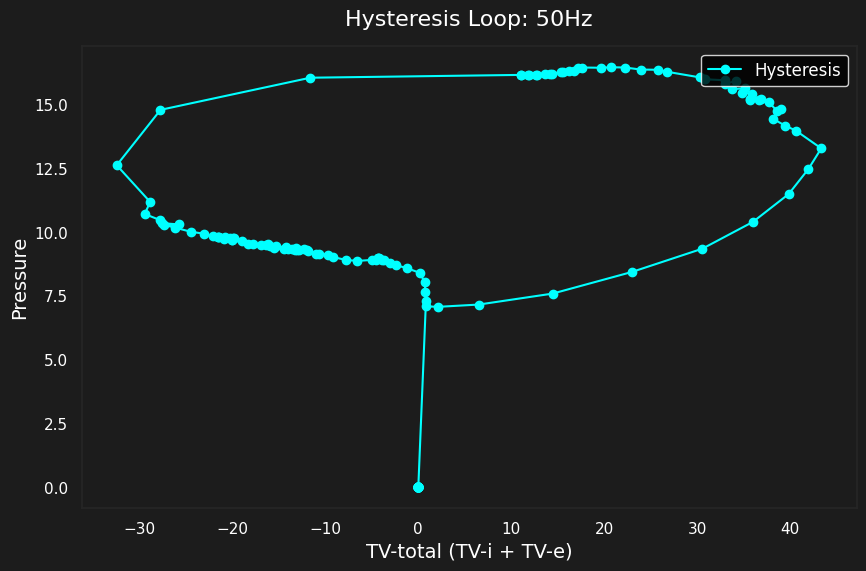

In [30]:
Picaso.Draw_Cycle(breath_id=300)

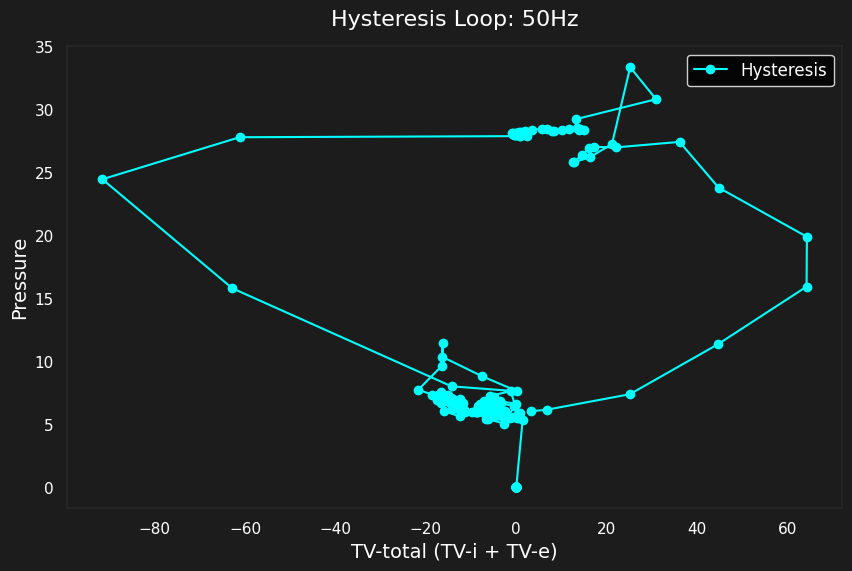

In [ ]:
Picaso.Draw_Cycle(breath_id=180)

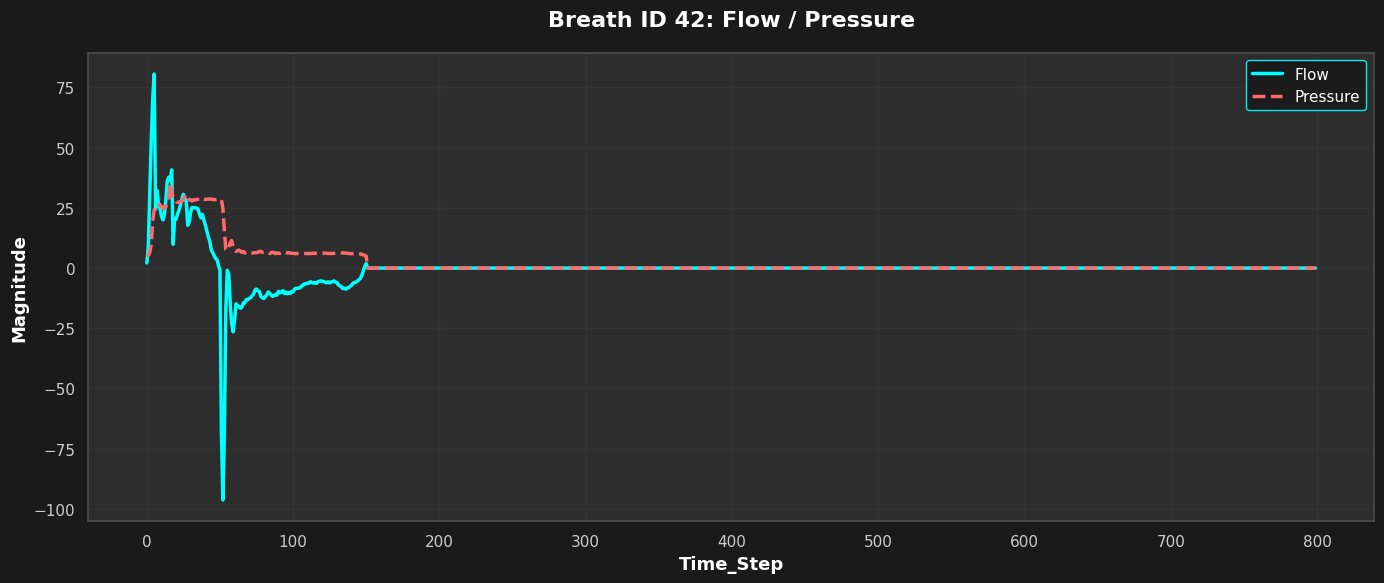

In [27]:
Picaso.draw_feature(breath_id=42, target='Flow')

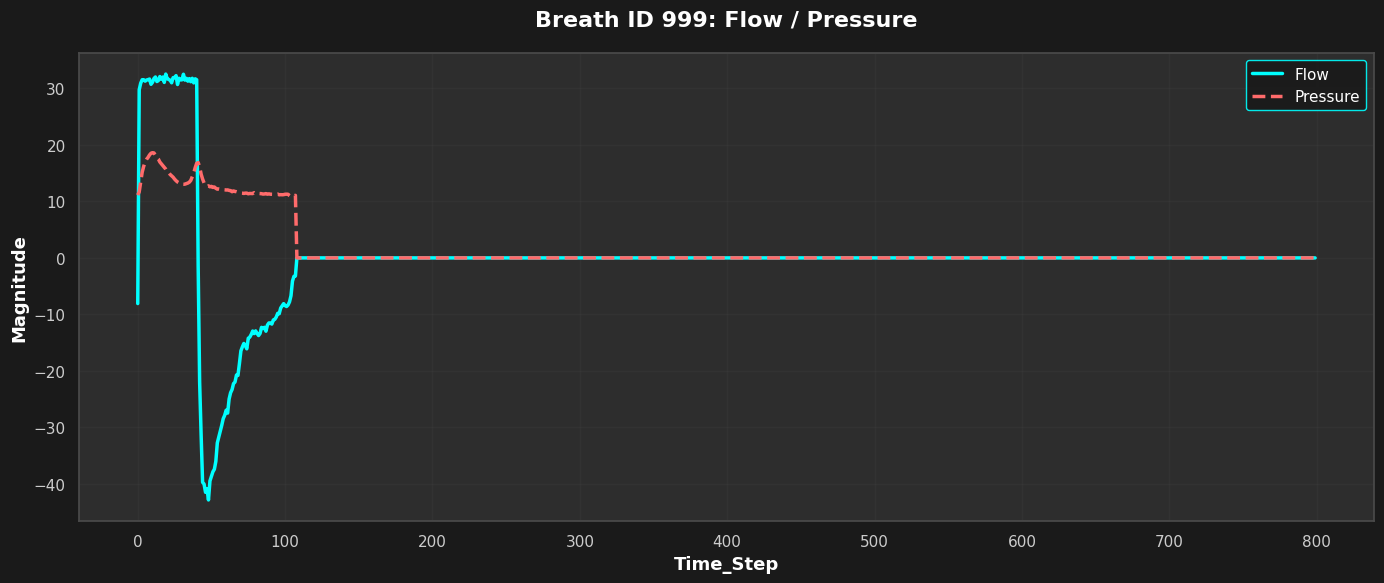

In [26]:
Picaso.draw_feature(breath_id=999, target='Flow')